# Microenvironment definition with `Cellina-GAT` (crc_210)

Reproduces the **microenvironment definition** step of `01_data_prep.ipynb` using the GAT
variant (`CellinaGCN(convolution_type='gat')`) in place of the base `Cellina` model.
No counterfactuals.

**Deliverable:** a trained `Cellina-GAT` model on `crc_210` and a set of Hotspot-derived
microenvironment labels — target is simply **>= 2 modules**. Section 9 is an optional,
fully-guarded FYI check that per-edge attention is extractable for a possible later analysis;
it is not part of this notebook's result.

## What differs from the reference run

Reference = `cellina-reproducibility/notebooks/application/01_data_prep.ipynb`, whose saved
output (`output/adata_with_microenv.h5ad`) contains **4** CRC microenvironments
(CRC1 103,516 / CRC2 65,232 / CRC3 95,988 / CRC4 66,652 over 331,388 CRC cells).

| | reference | this notebook | why |
|---|---|---|---|
| spatial encoder | MLP on precomputed `spatial_x` | GATv2, 2 hops, `heads=1` | the point of the run |
| spatial graph | `max_neighbours=200` | `max_neighbours=20` | 2 hops x 20 ~ 200 cells of context; keeps GAT VRAM sane |
| `n_layers` | 3 | 2 | tutorial params |
| `batch_size` | 4096 | 2048 (1024 on OOM) | tutorial params |
| `max_epochs` | 100 | 20 | reference's own best checkpoint was `epoch=15`, so ES fired around there anyway |

Model hyperparameters otherwise follow `docs/tutorial.ipynb`: `n_latent=64`, `n_layers=2`,
`use_observed_lib_size=True`, `condition_on_intrinsic=False`, `gene_likelihood='nb'`,
`classifier_lambda=1`, `discriminator_lambda=1`, `lr=1e-3`, `normalize_losses=True`.
GAT-only params stay at their shipped defaults (`link_prediction_weight=1`,
`spatial_loss_type='supcon'`, `supcon_temperature=0.25`, `n_hidden=128`,
`subgraph_type='induced'`, `heads=1`).

**Hotspot parameters are deliberately identical to the reference** (`n_neighbors=30`,
top 1200 genes at FDR<0.05, `min_gene_threshold=100`, `core_only=True`) so that any change
in module count is attributable to the latent space, not to the clustering.

## Caveats recorded up front
- `GraphJointDataSplitter` splits **seed nodes only**; the full `edge_index` is used for message
  passing in every split. The 10% holdout is therefore *not* a leak-free holdout for the GAT.
  It exists only to mirror the reference split, and no generalisation claim is made from it.
- Microenvironments are a hard partition via `module_scores.idxmax` — every CRC cell gets a
  label even where all module scores are near zero. This matches the reference.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import json
import time

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import torch

# helpers live in the reproducibility repo: set_seed in utils.py, preprocessing in train_loo.py
SCRIPTS = "/data/ddimitrov/repos/cellina-reproducibility/scripts"
sys.path.append(SCRIPTS)
from utils import set_seed
from train_loo import preprocess_crc

import cellina
from cellina import CellinaGCN
from cellina._spatial_utils import spatial_neighbors

from scvi.train._callbacks import SaveCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    normalized_mutual_info_score as nmi,
    adjusted_rand_score as ari,
    silhouette_score,
)

plt.rcParams["font.family"] = "monospace"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 80

print("cellina", cellina.__version__)
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())

cellina 0.99.1
torch 2.4.1 | cuda True


In [3]:
# ---------------- config ----------------
SLIDE_ID  = "crc_210"
DATA_PATH = f"/data/a330d/datasets/crc/raw_zenodo/{SLIDE_ID}.h5ad"

LABELS_KEY, DOMAINS_KEY, BATCH_KEY = "coarse_type", "typ_clean", "sid"

# spatial graph (build time)
GRAPH_K   = 20
BANDWIDTH = 100 / 0.12028          # as in the reference run

# model -- tutorial params
N_LATENT      = 64
N_LAYERS      = 2
NUM_NEIGHBORS = [GRAPH_K] * N_LAYERS   # no-op ceiling: graph degree is already <= GRAPH_K
CONV_TYPE     = "gat"
SUBGRAPH_TYPE = "induced"

# training
BATCH_SIZE  = 2048
FALLBACK_BS = 1024                 # used only on CUDA OOM
MAX_EPOCHS  = 20
ES_PATIENCE = 10
MONITOR     = "vae_loss_validation"
LR          = 1e-3
GPU         = 0
SEED        = 1337                 # as in application/01_data_prep.ipynb

# hotspot -- UNCHANGED from the reference run
HS_NEIGHBORS  = 30
HS_TOPK       = 1200
HS_MIN_GENES  = 100
HS_FDR        = 0.05
HS_JOBS       = 24
HS_SEED       = 0

# gate + preview
GATE_NMI_MIN = 0.10
LEIDEN_RES   = 1.0
UMAP_FRAC    = 0.1
PREVIEW_N    = 50_000

# paths
MODEL_DIR = f"./{SLIDE_ID}_gat"    # NOT ./crc_210 -- that holds old base-Cellina checkpoints
OUT_DIR   = "./output"
RES_DIR   = f"../results/analysis/{SLIDE_ID}_gat"
LCZ_PATH  = f"{RES_DIR}/hotspot_lcz_crc_gat.csv"
H5AD_OUT  = f"{OUT_DIR}/{SLIDE_ID}_gat_microenv.h5ad"
REF_H5AD  = ("/data/ddimitrov/repos/cellina-reproducibility/notebooks/"
             "application/output/adata_with_microenv.h5ad")

RETRAIN = False                    # False -> load existing checkpoint from MODEL_DIR
MIN_FREE_GB = 3                    # refuse the big h5ad write below this (shared, full disk)
AC_PATH = f"{RES_DIR}/hotspot_autocorrelations.csv"   # cached like LCZ_PATH

for d in (MODEL_DIR, OUT_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

summary = {}   # collected metrics, written to disk at the end

## 1. Data

In [4]:
set_seed(SEED)

t0 = time.time()
adata = sc.read(DATA_PATH)
adata.obs_names_make_unique()
print(f"loaded {adata.shape} in {time.time()-t0:.0f}s")

loaded (617498, 18936) in 9s


In [5]:
# preprocess_crc: maps ist -> coarse_type, extracts typ_clean from typ, sets obsm['spatial'],
# filters cells/genes, HVG 2000 (seurat_v3), stores layers['counts'] and resets X to counts.
adata = preprocess_crc(adata)

# preprocess_crc filters NaNs on `typ`, but the model uses `typ_clean` -- which it *creates*
# via regex and never re-checks. Guard against values that matched neither REF/TVA/CRC.
n_bad = int(adata.obs[DOMAINS_KEY].isna().sum())
print("typ_clean NaN:", n_bad)
if n_bad:
    adata = adata[~adata.obs[DOMAINS_KEY].isna()].copy()
adata.obs[DOMAINS_KEY] = adata.obs[DOMAINS_KEY].astype("category")

print(adata)
print(adata.obs[DOMAINS_KEY].value_counts())
print(adata.obs[LABELS_KEY].value_counts())
print("sid categories:", adata.obs[BATCH_KEY].nunique())
summary["n_cells"], summary["n_genes"] = int(adata.n_obs), int(adata.n_vars)

/data/ddimitrov/repos/cellina-reproducibility/scripts/train_loo.py:179: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


typ_clean NaN: 0
AnnData object with n_obs × n_vars = 552241 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'f

graph built in 4s -> obsp['spatial_connectivities']
count    552241.0
mean         20.0
std           0.0
min          20.0
25%          20.0
50%          20.0
75%          20.0
max          20.0
dtype: float64
isolated cells: 0 (0.0000%)


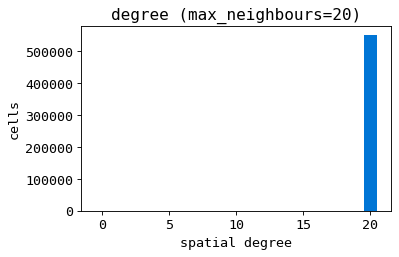

In [6]:
# Spatial graph. preprocess_crc no longer builds it, and preprocess_spatial_features would
# additionally log1p X in place and compute `spatial_x` -- neither is needed by the GAT,
# which log-transforms internally and consumes the graph directly.
t0 = time.time()
spatial_neighbors(adata, bandwidth=BANDWIDTH, max_neighbours=GRAPH_K, standardize=False)
print(f"graph built in {time.time()-t0:.0f}s -> obsp['spatial_connectivities']")

A = adata.obsp["spatial_connectivities"]
deg = np.asarray((A > 0).sum(axis=1)).ravel()
print(pd.Series(deg).describe())

n_iso = int((deg == 0).sum())
print(f"isolated cells: {n_iso} ({100*n_iso/len(deg):.4f}%)")
if n_iso:
    print("NOTE: isolated cells have no neighbours to attend over; their `s` carries no context.")

summary["degree_mean"] = float(deg.mean())
summary["degree_max"] = int(deg.max())
summary["n_isolated"] = n_iso
summary["n_edges"] = int(A.nnz)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(deg, bins=np.arange(deg.max() + 2) - 0.5, color="#0075D5")
ax.set_xlabel("spatial degree"); ax.set_ylabel("cells")
ax.set_title(f"degree (max_neighbours={GRAPH_K})")
plt.show()

## 2. Data splits

Random 10% holdout + 10% validation, as in `application/01_data_prep.ipynb`.

In [7]:
fraction = 0.1
n_holdout = int(adata.n_obs * fraction)
test_idx = np.random.choice(adata.n_obs, n_holdout, replace=False)

all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

adata.obs["is_holdout"] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc("is_holdout")] = True

train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.1, random_state=0, shuffle=True,
)
print("train:", len(train_idx), "| val:", len(val_idx), "| test:", len(test_idx))

train: 447315 | val: 49702 | test: 55224


## 3. Train `Cellina-GAT`

In [8]:
CellinaGCN.setup_anndata(
    adata,
    batch_key=BATCH_KEY,
    labels_key=LABELS_KEY,
    domains_key=DOMAINS_KEY,
    layer="counts",
    spatial_connectivities_key="spatial_connectivities",
)

MODEL_ARGS = dict(
    n_latent=N_LATENT,
    n_layers=N_LAYERS,
    use_observed_lib_size=True,
    condition_on_intrinsic=False,
    gene_likelihood="nb",
    classifier_lambda=1.0,
    discriminator_lambda=1.0,
    spatial_loss_type="supcon",
    num_neighbors=NUM_NEIGHBORS,
    convolution_type=CONV_TYPE,
    subgraph_type=SUBGRAPH_TYPE,
)
PLAN_KWARGS = dict(lr=LR, normalize_losses=True)

def make_train_args(bs):
    return dict(
        max_epochs=MAX_EPOCHS,
        batch_size=bs,
        check_val_every_n_epoch=1,
        early_stopping=True,
        devices=[GPU],
        enable_checkpointing=True,
        datasplitter_kwargs={"external_indexing": [train_idx, val_idx, test_idx]},
        callbacks=[
            SaveCheckpoint(monitor=MONITOR, dirpath=MODEL_DIR, load_best_on_end=True),
            EarlyStopping(monitor=MONITOR, patience=ES_PATIENCE, mode="min"),
        ],
    )

print(json.dumps({k: str(v) for k, v in MODEL_ARGS.items()}, indent=2))

{
  "n_latent": "64",
  "n_layers": "2",
  "use_observed_lib_size": "True",
  "condition_on_intrinsic": "False",
  "gene_likelihood": "nb",
  "classifier_lambda": "1.0",
  "discriminator_lambda": "1.0",
  "spatial_loss_type": "supcon",
  "num_neighbors": "[20, 20]",
  "convolution_type": "gat",
  "subgraph_type": "induced"
}


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [9]:
existing = sorted(os.listdir(MODEL_DIR)) if os.path.isdir(MODEL_DIR) else []

if not RETRAIN and existing:
    print("loading existing checkpoint:", existing[0])
    model = CellinaGCN.load(f"{MODEL_DIR}/{existing[0]}", adata=adata)
    used_bs = BATCH_SIZE
else:
    model = None
    for bs in (BATCH_SIZE, FALLBACK_BS):
        try:
            torch.cuda.empty_cache()
            model = CellinaGCN(adata, **MODEL_ARGS)
            t0 = time.time()
            model.train(**make_train_args(bs), plan_kwargs=PLAN_KWARGS)
            used_bs = bs
            mins = (time.time() - t0) / 60
            print(f"trained at batch_size={bs} in {mins:.1f} min")
            summary["train_minutes"] = round(mins, 1)
            break
        except torch.cuda.OutOfMemoryError as err:
            print(f"CUDA OOM at batch_size={bs}: {err}")
            model = None
            torch.cuda.empty_cache()
            if bs == FALLBACK_BS:
                raise

summary["batch_size_used"] = int(used_bs)
summary["peak_vram_gb"] = round(torch.cuda.max_memory_allocated() / 1e9, 2)
print("peak VRAM (GB):", summary["peak_vram_gb"])

loading existing checkpoint: epoch=19-step=8322-vae_loss_validation=306.0075378417969
INFO     File ./crc_210_gat/epoch=19-step=8322-vae_loss_validation=306.0075378417969/model.pt already downloaded   


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = to

INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


peak VRAM (GB): 0.02


In [ ]:
hist = model.history_
if hist is None:
    # RETRAIN=False: this process never trained, so Lightning kept no history.
    # Trajectory from the training run (checkpoint filenames):
    #   epoch 1: 324.96 -> 3: 312.90 -> 8: 309.17 -> 11: 308 -> 14: 306 -> 19: 306.01
    print("no in-process training history (RETRAIN=False); skipping loss curves")
else:
    print({k: float(v.iloc[-1].item()) for k, v in hist.items() if "validation" in k})

    track = [k for k in ("vae_loss_validation", "elbo_validation",
                         "reconstruction_loss_validation", "spatial_loss_validation")
             if k in hist]
    fig, axes = plt.subplots(1, len(track), figsize=(4 * len(track), 3))
    axes = np.atleast_1d(axes)
    for ax, k in zip(axes, track):
        ax.plot(hist[k].index, hist[k].values, marker="o", ms=3)
        ax.set_title(k, fontsize=9); ax.set_xlabel("epoch")
        summary[f"best_{k}"] = float(hist[k].min().item())
    plt.tight_layout(); plt.show()


no in-process training history (RETRAIN=False); skipping loss curves


## 4. Latent representations

In [11]:
t0 = time.time()
adata.obsm["cellina_basal"] = model.get_latent_representation(
    adata=adata, latent_key="z", batch_size=used_bs)
adata.obsm["cellina_spatial"] = model.get_latent_representation(
    adata=adata, latent_key="s", batch_size=used_bs)
print(f"inference in {(time.time()-t0)/60:.1f} min",
      adata.obsm["cellina_basal"].shape, adata.obsm["cellina_spatial"].shape)

inference in 0.5 min (552241, 64) (552241, 64)


UMAP subsample: 55224


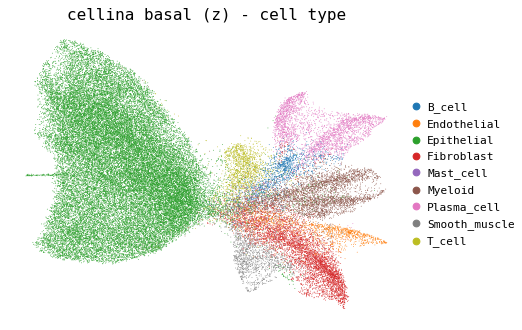

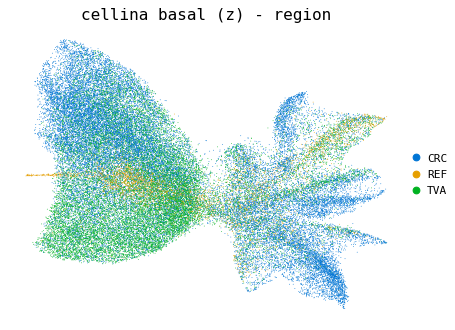

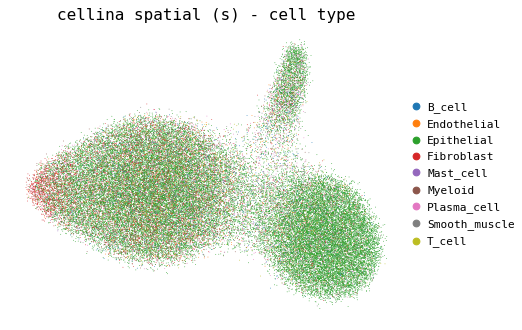

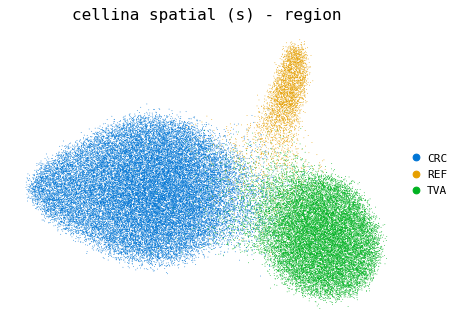

In [12]:
rng = np.random.default_rng(0)
sub = np.sort(rng.choice(adata.n_obs, int(adata.n_obs * UMAP_FRAC), replace=False))
adata_sub = adata[sub].copy()
print("UMAP subsample:", adata_sub.n_obs)

palette = {"REF": "#E69F00", "CRC": "#0075D5", "TVA": "#00B221"}

for rep, title in [("cellina_basal", "cellina basal (z)"),
                   ("cellina_spatial", "cellina spatial (s)")]:
    sc.pp.neighbors(adata_sub, use_rep=rep)
    sc.tl.umap(adata_sub)
    adata_sub.obsm[f"X_umap_{rep}"] = adata_sub.obsm["X_umap"].copy()
    sc.pl.umap(adata_sub, color=[LABELS_KEY], title=f"{title} - cell type",
               frameon=False, show=True)
    sc.pl.umap(adata_sub, color=[DOMAINS_KEY], title=f"{title} - region",
               palette=palette, frameon=False, show=True)

In [13]:
# ---- GATE: is `s` actually organised by region? ----
# Quantitative because this runs headless. Disentanglement predicts NMI(s) >> NMI(z):
# the adversary pushes domain signal out of z, supcon pulls it into s.
sc.pp.neighbors(adata_sub, use_rep="cellina_spatial")
sc.tl.leiden(adata_sub, resolution=LEIDEN_RES, key_added="leiden_s",
             flavor="igraph", n_iterations=2, directed=False)
sc.pp.neighbors(adata_sub, use_rep="cellina_basal")
sc.tl.leiden(adata_sub, resolution=LEIDEN_RES, key_added="leiden_z",
             flavor="igraph", n_iterations=2, directed=False)

dom = adata_sub.obs[DOMAINS_KEY].astype(str).values
ctype = adata_sub.obs[LABELS_KEY].astype(str).values

nmi_s_dom = nmi(dom, adata_sub.obs["leiden_s"].astype(str).values)
nmi_z_dom = nmi(dom, adata_sub.obs["leiden_z"].astype(str).values)
nmi_s_ct = nmi(ctype, adata_sub.obs["leiden_s"].astype(str).values)
nmi_z_ct = nmi(ctype, adata_sub.obs["leiden_z"].astype(str).values)

asw_idx = np.sort(rng.choice(adata_sub.n_obs, min(20_000, adata_sub.n_obs), replace=False))
asw_s = silhouette_score(adata_sub.obsm["cellina_spatial"][asw_idx], dom[asw_idx])
asw_z = silhouette_score(adata_sub.obsm["cellina_basal"][asw_idx], dom[asw_idx])

print(f"NMI(leiden | region)     s={nmi_s_dom:.3f}   z={nmi_z_dom:.3f}")
print(f"NMI(leiden | cell type)  s={nmi_s_ct:.3f}   z={nmi_z_ct:.3f}")
print(f"ASW(region)              s={asw_s:.3f}   z={asw_z:.3f}")
print(f"leiden clusters          s={adata_sub.obs['leiden_s'].nunique()}"
      f"   z={adata_sub.obs['leiden_z'].nunique()}")

summary.update(nmi_s_domain=round(float(nmi_s_dom), 4), nmi_z_domain=round(float(nmi_z_dom), 4),
               nmi_s_celltype=round(float(nmi_s_ct), 4), nmi_z_celltype=round(float(nmi_z_ct), 4),
               asw_s_domain=round(float(asw_s), 4), asw_z_domain=round(float(asw_z), 4))

GATE_PASS = bool(nmi_s_dom >= GATE_NMI_MIN and nmi_s_dom > nmi_z_dom)
summary["gate_pass"] = GATE_PASS
print("\n" + ("=" * 62))
if GATE_PASS:
    print(f"GATE PASS: s is region-structured (NMI {nmi_s_dom:.3f} >= {GATE_NMI_MIN}"
          f" and > z's {nmi_z_dom:.3f}).")
else:
    print(f"GATE FAIL: s is NOT clearly region-structured (NMI {nmi_s_dom:.3f},"
          f" threshold {GATE_NMI_MIN}, z={nmi_z_dom:.3f}).")
    print("Continuing anyway to record the module count, but treat modules as suspect:")
    print("  first suspects = graph k=20 (vs 200), batch size (supcon negatives), 20-epoch cap.")
print("=" * 62)

NMI(leiden | region)     s=0.686   z=0.078
NMI(leiden | cell type)  s=0.030   z=0.475
ASW(region)              s=0.104   z=-0.036
leiden clusters          s=4   z=17

GATE PASS: s is region-structured (NMI 0.686 >= 0.1 and > z's 0.078).


## 5. Leiden preview within CRC

Cheap proxy for "is there multi-cluster structure in `s` inside the tumour" — minutes rather
than the ~30-60 min Hotspot takes. Not a substitute for Hotspot: Leiden partitions cells,
Hotspot finds co-varying *gene* modules and then scores cells on them.

CRC cells: 331388


Leiden clusters on s within CRC (n=50000, res=1.0): 27
leiden_crc
26    10237
0      9644
14     2270
12     1905
6      1855
17     1788
16     1675
13     1525
7      1440
9      1409
25     1383
2      1148
11     1125
20     1121
8      1115
Name: count, dtype: int64


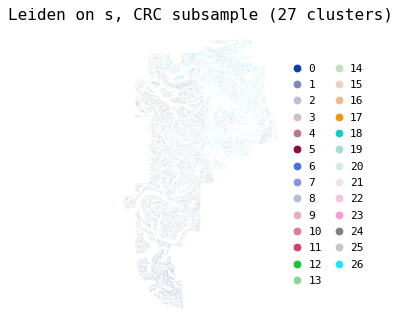

In [14]:
crc_mask = adata.obs[DOMAINS_KEY].astype(str).str.contains("CRC")
adata_crc = adata[crc_mask].copy()
print("CRC cells:", adata_crc.n_obs)
summary["n_crc_cells"] = int(adata_crc.n_obs)

prev_idx = np.sort(rng.choice(adata_crc.n_obs, min(PREVIEW_N, adata_crc.n_obs), replace=False))
prev = adata_crc[prev_idx].copy()
sc.pp.neighbors(prev, use_rep="cellina_spatial")
sc.tl.leiden(prev, resolution=LEIDEN_RES, key_added="leiden_crc",
             flavor="igraph", n_iterations=2, directed=False)

n_leiden = int(prev.obs["leiden_crc"].nunique())
print(f"Leiden clusters on s within CRC (n={prev.n_obs}, res={LEIDEN_RES}): {n_leiden}")
print(prev.obs["leiden_crc"].value_counts().head(15))
summary["n_leiden_crc"] = n_leiden

sc.pl.spatial(prev, color="leiden_crc", spot_size=60, frameon=False,
              title=f"Leiden on s, CRC subsample ({n_leiden} clusters)", show=True)

## 6. Hotspot modules

Parameters identical to the reference run. The only changed input is `cellina_spatial`.

In [15]:
import hotspot

set_seed(HS_SEED)   # reproducible hotspot KNN + module detection

hs = hotspot.Hotspot(
    adata_crc,
    layer_key="counts",
    model="danb",
    latent_obsm_key="cellina_spatial",
    umi_counts_obs_key="nCount_RNA",
)
hs.create_knn_graph(weighted_graph=False, n_neighbors=HS_NEIGHBORS)

if os.path.exists(AC_PATH):
    print("loading cached autocorrelations:", AC_PATH)
    hs_results = pd.read_csv(AC_PATH, index_col=0)
    hs.results = hs_results
else:
    t0 = time.time()
    hs_results = hs.compute_autocorrelations(jobs=HS_JOBS)
    print(f"autocorrelations in {(time.time()-t0)/60:.1f} min")
    hs_results.to_csv(AC_PATH)
hs_results.head()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 1/2000 [00:00<12:11,  2.73it/s]

  0%|          | 2/2000 [00:00<09:21,  3.56it/s]

  0%|          | 9/2000 [00:00<01:51, 17.83it/s]

  1%|          | 22/2000 [00:00<00:51, 38.45it/s]

...

 98%|█████████▊| 1955/2000 [00:07<00:00, 257.70it/s]

 99%|█████████▉| 1988/2000 [00:07<00:00, 275.99it/s]

100%|██████████| 2000/2000 [00:07<00:00, 253.12it/s]

autocorrelations in 0.2 min


,C,Z,Pval,FDR
Gene,,,,
COL1A1,0.149695,1325.443649,0.0,0.0
MMP2,0.074035,626.142639,0.0,0.0
FN1,0.123557,588.415726,0.0,0.0
COL3A1,0.076059,548.425275,0.0,0.0
SPARC,0.073461,500.292732,0.0,0.0


In [16]:
hs_genes = hs_results.loc[hs_results.FDR < HS_FDR].head(HS_TOPK).index
print(f"genes with FDR<{HS_FDR}: {(hs_results.FDR < HS_FDR).sum()} -> using top {len(hs_genes)}")

if os.path.exists(LCZ_PATH):
    print("loading cached lcz:", LCZ_PATH)
    lcz = pd.read_csv(LCZ_PATH, index_col=0)
    hs.local_correlation_z = lcz
else:
    t0 = time.time()
    lcz = hs.compute_local_correlations(hs_genes, jobs=HS_JOBS)
    print(f"local correlations in {(time.time()-t0)/60:.1f} min")
    lcz.to_csv(LCZ_PATH)
print(lcz.shape)

genes with FDR<0.05: 1046 -> using top 1046
loading cached lcz: ../results/analysis/crc_210_gat/hotspot_lcz_crc_gat.csv
(1047, 1047)


In [17]:
modules = hs.create_modules(
    min_gene_threshold=HS_MIN_GENES, core_only=True, fdr_threshold=HS_FDR,
)
module_scores = hs.calculate_module_scores()

n_modules = int(module_scores.shape[1])
print(f"MODULES FOUND: {n_modules}  -> {sorted(module_scores.columns)}")
print("\ngenes per module (-1 = unassigned):")
print(modules.value_counts().sort_index())
summary["n_modules"] = n_modules
summary["genes_per_module"] = {str(k): int(v) for k, v in modules.value_counts().items()}
module_scores.head()

Computing scores for 3 modules...


  0%|          | 0/3 [00:00<?, ?it/s]

 33%|███▎      | 1/3 [00:17<00:35, 17.51s/it]

 67%|██████▋   | 2/3 [00:28<00:13, 13.56s/it]

100%|██████████| 3/3 [00:33<00:00,  9.67s/it]

100%|██████████| 3/3 [00:33<00:00, 11.11s/it]

MODULES FOUND: 3  -> [1, 2, 3]

genes per module (-1 = unassigned):
Module
-1    204
 1    438
 2    276
 3    129
Name: count, dtype: int64


,1,2,3
c_1_1_1,-0.841936,1.943915,-0.191840
c_1_1_2,-1.505488,3.228745,0.077184
c_1_1_3,-0.499144,1.900490,0.182506
c_1_1_4,-1.085444,1.256675,1.188001
c_1_1_5,-0.901580,2.452949,-0.544571


In [18]:
for c in module_scores.columns:
    adata_crc.obs[f"Module {c}"] = module_scores[c]
adata_crc.obsm["module_scores"] = module_scores.loc[adata_crc.obs_names].values

# hard partition by argmax, as in the reference
adata_crc.obs["top_module"] = module_scores.idxmax(axis=1).astype(str).astype("category")
adata_crc.obs["microenvironment"] = pd.Categorical(
    adata_crc.obs["top_module"].astype(str).map(lambda x: f"CRC{x}")
)
print(adata_crc.obs["microenvironment"].value_counts())
summary["microenv_counts"] = {
    str(k): int(v) for k, v in adata_crc.obs["microenvironment"].value_counts().items()
}

microenvironment
CRC2    137339
CRC3    106419
CRC1     87630
Name: count, dtype: int64


In [19]:
# map back onto the full slide; non-CRC cells keep their original `typ`
me = adata_crc.obs["microenvironment"].astype(str).reindex(adata.obs_names)
adata.obs["microenvironment"] = pd.Categorical(me.fillna(adata.obs["typ"].astype(str)))
print(adata.obs["microenvironment"].value_counts())

microenvironment
210_TVA    185092
CRC2       137339
CRC3       106419
CRC1        87630
210_REF     35761
Name: count, dtype: int64


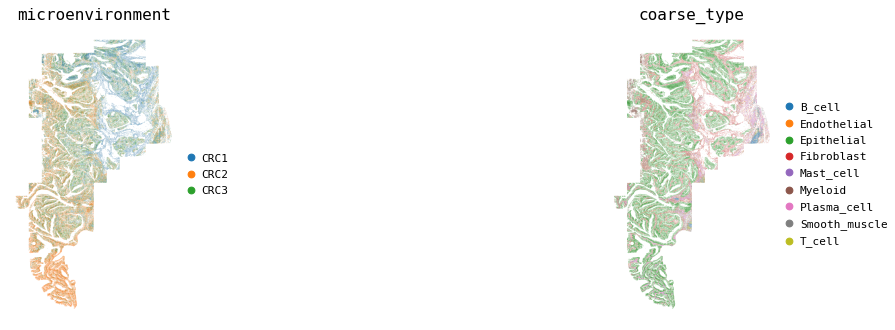

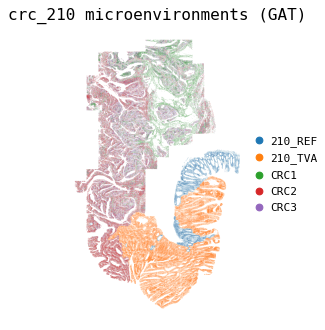

In [20]:
sc.pl.spatial(adata_crc, color=["microenvironment", LABELS_KEY],
              spot_size=50, frameon=False, wspace=0.3, show=True)
sc.pl.spatial(adata, color="microenvironment", spot_size=50, frameon=False,
              title=f"{SLIDE_ID} microenvironments (GAT)", show=True)

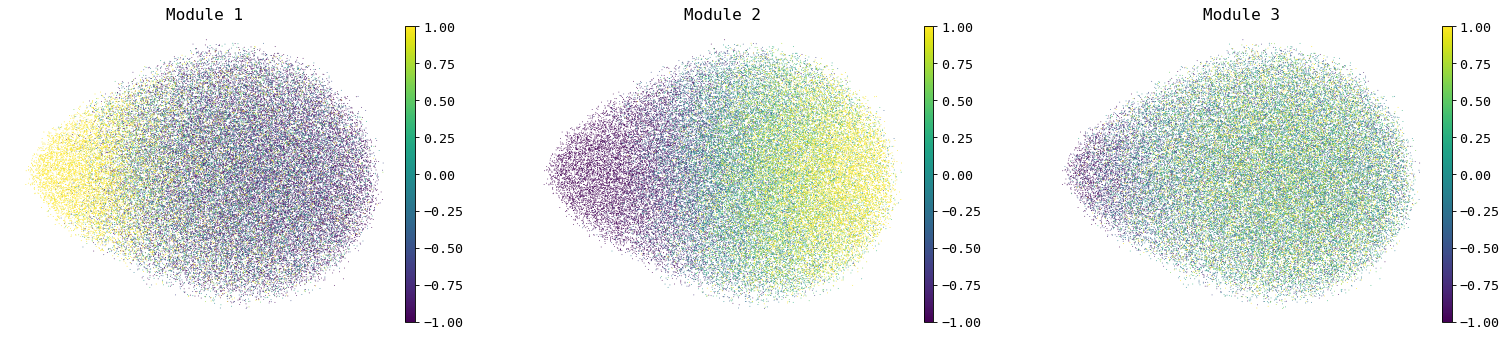

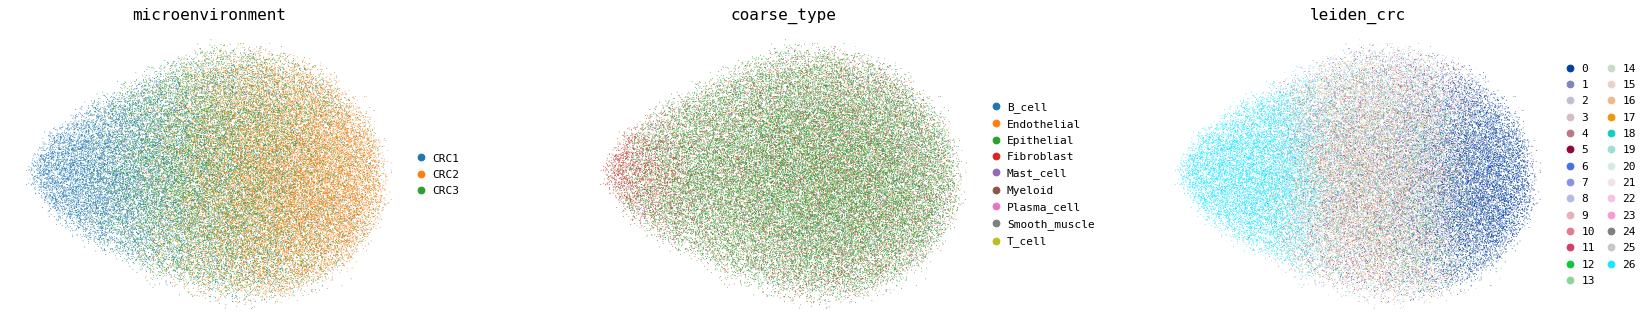

In [21]:
# `prev` already has a cellina_spatial neighbour graph from section 5
mod_cols = [f"Module {c}" for c in module_scores.columns]
for c in module_scores.columns:
    prev.obs[f"Module {c}"] = module_scores.loc[prev.obs_names, c].values
prev.obs["microenvironment"] = adata_crc.obs.loc[prev.obs_names, "microenvironment"].values

sc.tl.umap(prev)
sc.pl.umap(prev, color=mod_cols, frameon=False, vmin=-1, vmax=1, wspace=0.2, show=True)
sc.pl.umap(prev, color=["microenvironment", LABELS_KEY, "leiden_crc"],
           frameon=False, wspace=0.3, show=True)

## 7. Comparison against the reference labels (diagnostic only)

The reference run's labels are on disk, so we can ask whether this is the *same partition*
rather than only the same count. Read in backed mode — we need `obs` only, not `X`.

In [22]:
try:
    ref = ad.read_h5ad(REF_H5AD, backed="r")
    ref_me = ref.obs["microenvironment"].astype(str)

    common = adata_crc.obs_names.intersection(ref.obs_names)
    a = adata_crc.obs.loc[common, "microenvironment"].astype(str)
    b = ref_me.loc[common]
    both_crc = b.str.startswith("CRC").values

    print(f"obs_names overlap: {len(common)} | ref-CRC among them: {int(both_crc.sum())}")
    print("reference microenvironments:", sorted(b[both_crc].unique()))

    av, bv = a.values[both_crc], b.values[both_crc]
    m_nmi, m_ari = nmi(bv, av), ari(bv, av)
    print(f"\nNMI(new, reference) = {m_nmi:.4f}")
    print(f"ARI(new, reference) = {m_ari:.4f}")
    summary["nmi_vs_reference"] = round(float(m_nmi), 4)
    summary["ari_vs_reference"] = round(float(m_ari), 4)
    summary["n_ref_modules"] = int(len(set(bv)))

    ct = pd.crosstab(pd.Series(av, name="GAT"), pd.Series(bv, name="reference"))
    print("\ncounts:"); print(ct)
    print("\nrow-normalised (each GAT microenvironment's split across reference ones):")
    print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))
    ref.file.close()
except Exception as err:
    print("reference comparison skipped:", type(err).__name__, err)

obs_names overlap: 331388 | ref-CRC among them: 331388
reference microenvironments: ['CRC1', 'CRC2', 'CRC3', 'CRC4']



NMI(new, reference) = 0.0993
ARI(new, reference) = 0.1029

counts:
reference   CRC1   CRC2   CRC3   CRC4
GAT                                  
CRC1       55690  10345   8620  12975
CRC2       18636  35344  62058  21301
CRC3       29190  19543  25310  32376

row-normalised (each GAT microenvironment's split across reference ones):
reference  CRC1  CRC2  CRC3  CRC4
GAT                              
CRC1       63.6  11.8   9.8  14.8
CRC2       13.6  25.7  45.2  15.5
CRC3       27.4  18.4  23.8  30.4


## 8. Save outputs

Ordered **cheapest-and-most-valuable first**. A previous run died writing the multi-GB h5ad on
a full disk and took every other result down with it, so the headline numbers are now durable
before the large write is attempted.

In [23]:
# --- 8a. small, must-succeed artifacts ---
with open(f"{RES_DIR}/summary.json", "w") as fh:
    json.dump(summary, fh, indent=2, default=str)
modules.to_frame("module").to_csv(f"{RES_DIR}/hotspot_modules_genes.csv")
adata_crc.obs[["top_module", "microenvironment"]].to_csv(f"{RES_DIR}/microenvironment_labels.csv")
module_scores.to_csv(f"{RES_DIR}/hotspot_module_scores.csv")
adata.obs[["microenvironment"]].to_csv(f"{RES_DIR}/microenvironment_labels_full.csv")
np.save(f"{RES_DIR}/cellina_spatial.npy", adata.obsm["cellina_spatial"].astype(np.float32))
np.save(f"{RES_DIR}/cellina_basal.npy", adata.obsm["cellina_basal"].astype(np.float32))
print("small artifacts written to", RES_DIR)
print(json.dumps(summary, indent=2, default=str))

small artifacts written to ../results/analysis/crc_210_gat
{
  "n_cells": 552241,
  "n_genes": 2000,
  "degree_mean": 20.0,
  "degree_max": 20,
  "n_isolated": 0,
  "n_edges": 11044820,
  "batch_size_used": 2048,
  "peak_vram_gb": 0.02,
  "nmi_s_domain": 0.6856,
  "nmi_z_domain": 0.0777,
  "nmi_s_celltype": 0.0295,
  "nmi_z_celltype": 0.4747,
  "asw_s_domain": 0.1044,
  "asw_z_domain": -0.036,
  "gate_pass": true,
  "n_crc_cells": 331388,
  "n_leiden_crc": 27,
  "n_modules": 3,
  "genes_per_module": {
    "1": 438,
    "2": 276,
    "-1": 204,
    "3": 129
  },
  "microenv_counts": {
    "CRC2": 137339,
    "CRC3": 106419,
    "CRC1": 87630
  },
  "nmi_vs_reference": 0.0993,
  "ari_vs_reference": 0.1029,
  "n_ref_modules": 4
}


In [24]:
# --- 8b. slim h5ad: obs/obsm/obsp only ---
# X and layers are omitted deliberately: they are ~2 GB and fully reconstructible via
# preprocess_crc(sc.read(DATA_PATH)), which is deterministic (seeded HVG selection).
import shutil

free_gb = shutil.disk_usage(OUT_DIR).free / 1e9
print(f"free space: {free_gb:.1f} GB")

if free_gb < MIN_FREE_GB:
    print(f"SKIPPING h5ad write: only {free_gb:.1f} GB free (< {MIN_FREE_GB} GB). "
          f"All results above are already saved in {RES_DIR}.")
else:
    t0 = time.time()
    slim = ad.AnnData(
        obs=adata.obs.copy(),
        var=adata.var.copy(),
        obsm={k: adata.obsm[k] for k in adata.obsm},
        obsp={"spatial_connectivities": adata.obsp["spatial_connectivities"]},
    )
    slim.uns["source_raw"] = DATA_PATH
    slim.uns["note"] = ("X/layers omitted to save disk; regenerate with "
                        "preprocess_crc(sc.read(source_raw)) then spatial_neighbors(...)")
    slim.uns["graph_max_neighbours"] = GRAPH_K
    slim.uns["bandwidth"] = BANDWIDTH
    slim.write(H5AD_OUT, compression="gzip")
    print(f"wrote {H5AD_OUT} ({os.path.getsize(H5AD_OUT)/1e9:.2f} GB) "
          f"in {(time.time()-t0)/60:.1f} min")

free space: 22.0 GB


wrote ./output/crc_210_gat_microenv.h5ad (0.66 GB) in 0.2 min


## 9. (Optional) attention-weight feasibility check

**Not part of phase 1.** Everything above is already saved, and this whole cell is wrapped in
`try/except` so it cannot affect the phase-1 result. It exists only to confirm that per-edge
attention is recoverable from this checkpoint, so phase 2 can start from a known-good handle.

Two non-obvious details it pins down:
- `GCNLayers.forward` feeds the conv a `torch_sparse.SparseTensor` (adj_t convention:
  `row=dst`, `col=src`), so `GATv2Conv(..., return_attention_weights=True)` returns a
  `SparseTensor` whose `.coo()` gives `(dst, src, alpha)` — not the usual tuple.
- The batch dict exposes only `node_indices` (seed ids), too little to label neighbour nodes.
  Iterating `GraphBatchLoader.node_loader` (the raw PyG loader) gives `.n_id`, the
  local→global map for *every* sampled node.

In [25]:
RUN_ATTENTION_CHECK = True

if RUN_ATTENTION_CHECK:
    try:
        from torch_sparse import SparseTensor
        from cellina._edge_data_splitter import _gather_dense_rows

        model.module.eval()
        dev = next(model.module.parameters()).device

        gbl = model._make_data_loader(adata=adata, indices=np.arange(8192), batch_size=256)
        node_batch = next(iter(gbl.node_loader))

        nid = node_batch.n_id.cpu().numpy()        # local -> global cell index
        edge_index = node_batch.edge_index.to(dev)
        bs_a = int(node_batch.batch_size)
        X = _gather_dense_rows(gbl.x_sparse, nid).to(dev)
        print(f"seed cells={bs_a} | sampled nodes={len(nid)} | edges={edge_index.shape[1]}")

        enc = model.module.s_encoder.encoder
        assert enc.n_cov == 0, f"covariate injection active (n_cov={enc.n_cov}); replicate it first"

        adj = SparseTensor(row=edge_index[1], col=edge_index[0],
                           sparse_sizes=(X.size(0), X.size(0)))

        atts, h = [], torch.log(1 + X)   # GAT input, matching CellinaGCNModule.inference
        with torch.no_grad():
            for i, layer in enumerate(enc.gcn_layers):
                h, att = layer(h, adj, return_attention_weights=True)
                atts.append(att)
                h = enc.activation_fn(enc.layer_norms[i](h))   # dropout=identity in eval

        for i, att in enumerate(atts):
            dst, src, alpha = att.coo()
            alpha = alpha.reshape(-1).float()
            sums = torch.zeros(X.size(0), device=dev).index_add_(0, dst, alpha)
            active = sums[sums > 0]
            print(f"layer {i}: alpha {tuple(alpha.shape)} "
                  f"range [{alpha.min():.4f}, {alpha.max():.4f}] | "
                  f"softmax-per-dst mean {active.mean():.6f}")
            assert torch.allclose(active, torch.ones_like(active), atol=1e-4)

        dst, src, alpha = atts[0].coo()
        dst_np = dst.cpu().numpy(); src_np = src.cpu().numpy()
        a_np = alpha.reshape(-1).cpu().numpy()
        keep = dst_np < bs_a
        att_df = pd.DataFrame({
            "dst_cell": adata.obs_names.values[nid[dst_np[keep]]],
            "src_cell": adata.obs_names.values[nid[src_np[keep]]],
            "dst_type": adata.obs[LABELS_KEY].values[nid[dst_np[keep]]],
            "src_type": adata.obs[LABELS_KEY].values[nid[src_np[keep]]],
            "alpha": a_np[keep],
        })
        print(f"\n{len(att_df)} seed-directed edges recovered; top attended:")
        print(att_df.nlargest(5, "alpha").to_string(index=False))
        print("\nattention is extractable and globally addressable (phase 2 unblocked).")
    except Exception as err:
        print("attention check failed (phase 1 results unaffected):", type(err).__name__, err)

seed cells=256 | sampled nodes=457 | edges=8507
layer 0: alpha (8507,) range [0.0001, 0.9115] | softmax-per-dst mean 1.000000
layer 1: alpha (8507,) range [0.0065, 0.2455] | softmax-per-dst mean 1.000000

5066 seed-directed edges recovered; top attended:
 dst_cell  src_cell   dst_type   src_type    alpha
 c_1_1_62 c_1_1_101 Epithelial Epithelial 0.911528
 c_1_1_52 c_1_1_101 Epithelial Epithelial 0.869239
 c_1_1_44 c_1_1_101    Myeloid Epithelial 0.841935
c_1_1_130 c_1_1_101 Epithelial Epithelial 0.779101
c_1_1_208 c_1_1_101 Epithelial Epithelial 0.760031

attention is extractable and globally addressable (phase 2 unblocked).
